In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

df = pd.read_csv("/Users/thunthita/LidarNRBPipeline/LIDar/csvfiles/25-03-2026/05.05.csv")
AfterPulse = pd.read_csv("/Users/thunthita/LidarNRBPipeline/LIDar/RawFile/AfterPulse.csv")
df

,analog,analog_sterr,photon_counting,pc_sterr,overflow_info
0,5.67729,0.000537,0.000000,0.000000,0.0
1,5.67719,0.000549,0.033515,0.023671,0.0
2,5.67824,0.000538,0.000000,0.000000,0.0
3,5.67797,0.000541,0.016757,0.016810,0.0
4,5.67770,0.000542,0.000000,0.000000,0.0
...,...,...,...,...,...
5019,5.67858,0.000000,0.000000,0.000000,0.0
5020,5.67835,0.000000,0.000000,0.000000,0.0
5021,5.67865,0.000000,0.016757,0.000000,0.0
5022,5.67810,0.000000,0.033515,0.000000,0.0


In [2]:
#parameter

#note: blend region shold be wider than overlap about 50 unit to make a smooth line
config = {
    "bin_width_ns": 25,
    "bin_spacing_m": 3.75,
    "prf_hz": 20,
    "dead_time_ns": 3.06,
    "bg_start_m": 0,
    "bg_end_m": 3750,
    "overlap_r1_m": 2600,
    "overlap_r2_m": 2800,
    "shift_search_bins": 20,
    "afterpulse_provided": True,
    "Sig_start": 3840,
    "Sig_end": 18836.25,
    "k_scale": 0.064021849,
    "b_offset": 0,
}


In [3]:
# add bin no. and bin_spacing 
bin_spacing_m = 3.75
range_m = 2000

# add bin_index (0, 1, 2, ...)
df.insert(0, "bin_index", np.arange(len(df)))

# add range_m (0, 3.75, 7.5, ...)
df.insert(1, "range_m", df["bin_index"] * bin_spacing_m)

#find signal to noise ratio
df["SNR_analog"] = df["analog"] / df["analog_sterr"]
df["SNR_Photon"] = df["photon_counting"] / df["pc_sterr"]

#Change MHz to Photon_per_bin
df["photon_per_bin"] = df["photon_counting"] * config["bin_width_ns"] * 1e-3

print(df.tail())

      bin_index   range_m   analog  analog_sterr  photon_counting  pc_sterr  \
5019       5019  18821.25  5.67858           0.0         0.000000       0.0   
5020       5020  18825.00  5.67835           0.0         0.000000       0.0   
5021       5021  18828.75  5.67865           0.0         0.016757       0.0   
5022       5022  18832.50  5.67810           0.0         0.033515       0.0   
5023       5023  18836.25  5.67785           0.0         0.016757       0.0   

      overflow_info  SNR_analog  SNR_Photon  photon_per_bin  
5019            0.0         inf         NaN        0.000000  
5020            0.0         inf         NaN        0.000000  
5021            0.0         inf         inf        0.000419  
5022            0.0         inf         inf        0.000838  
5023            0.0         inf         inf        0.000419  


In [4]:
print(df.tail())

      bin_index   range_m   analog  analog_sterr  photon_counting  pc_sterr  \
5019       5019  18821.25  5.67858           0.0         0.000000       0.0   
5020       5020  18825.00  5.67835           0.0         0.000000       0.0   
5021       5021  18828.75  5.67865           0.0         0.016757       0.0   
5022       5022  18832.50  5.67810           0.0         0.033515       0.0   
5023       5023  18836.25  5.67785           0.0         0.016757       0.0   

      overflow_info  SNR_analog  SNR_Photon  photon_per_bin  
5019            0.0         inf         NaN        0.000000  
5020            0.0         inf         NaN        0.000000  
5021            0.0         inf         inf        0.000419  
5022            0.0         inf         inf        0.000838  
5023            0.0         inf         inf        0.000419  


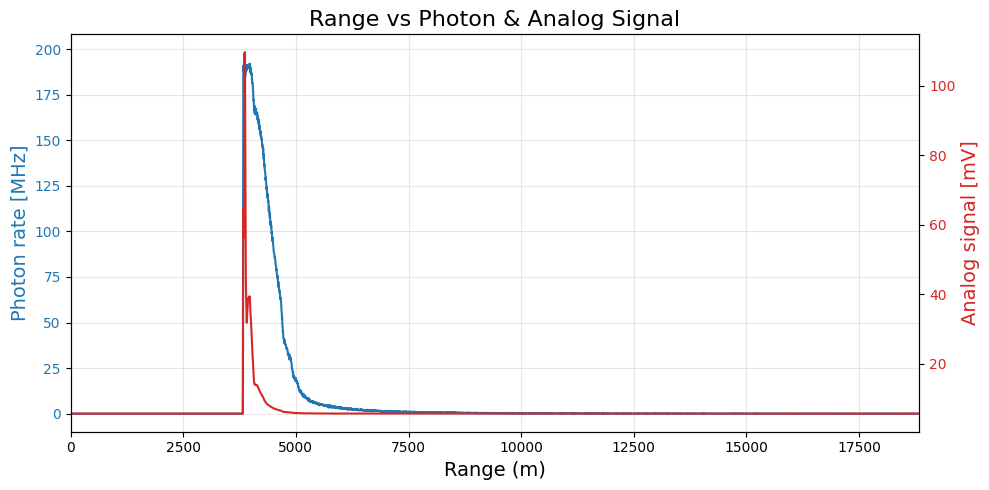

In [5]:
fig, ax1 = plt.subplots(figsize=(10,5))

# Left y-axis (Photon)
ax1.plot(df["range_m"], df["photon_counting"], color="tab:blue", label="Photon rate")
ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Photon rate [MHz]", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_xlim(0,18840)
ax1.grid(True, alpha=0.3)

# Right y-axis (Analog)
ax2 = ax1.twinx()
ax2.plot(df["range_m"], df["analog"], color="tab:red", label="Analog signal")
ax2.set_ylabel("Analog signal [mV]", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.set_xlim(0,18840)
plt.title("Range vs Photon & Analog Signal", fontsize=16)
plt.tight_layout()
plt.savefig("SPC/PCvsAC_Pre_plot.png", dpi=1000)
plt.show()

In [10]:
df_Sig = df[(df["range_m"] >= config["Sig_start"]) & (df["range_m"] <= config["Sig_end"])]
df_Sig["bin_index"] = df_Sig["bin_index"] - df_Sig["bin_index"].iloc[0]
df_Sig["range_m"] = df_Sig["bin_index"] * bin_spacing_m

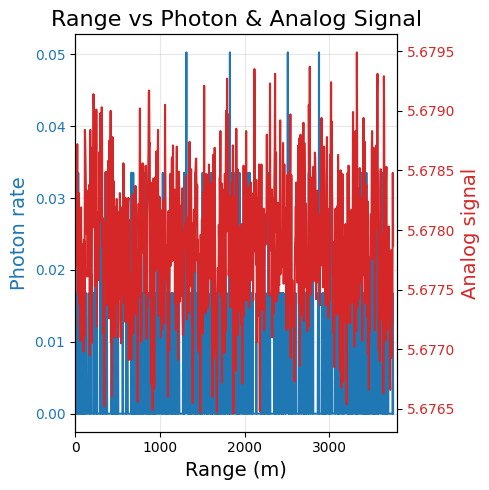

In [67]:
df_Pre = df[(df["range_m"] >= 0) & (df["range_m"] <= 3750)]
fig, ax1 = plt.subplots(figsize=(5,5))

# Left y-axis (Photon)
ax1.plot(df_Pre["range_m"], df_Pre["photon_counting"], color="tab:blue", label="Photon rate")
ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Photon rate", color="tab:blue", fontsize=14)
ax1.set_xlim(0,3800)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Right y-axis (Analog)
ax2 = ax1.twinx()
ax2.plot(df_Pre["range_m"], df_Pre["analog"], color="tab:red", label="Analog signal")
ax2.set_ylabel("Analog signal", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.set_xlim(0,3800)
plt.title("Range vs Photon & Analog Signal", fontsize=16)
plt.savefig("SPC/PCvsAC_Pretrig_only_plot.png", dpi=1000)
plt.tight_layout()
plt.show()


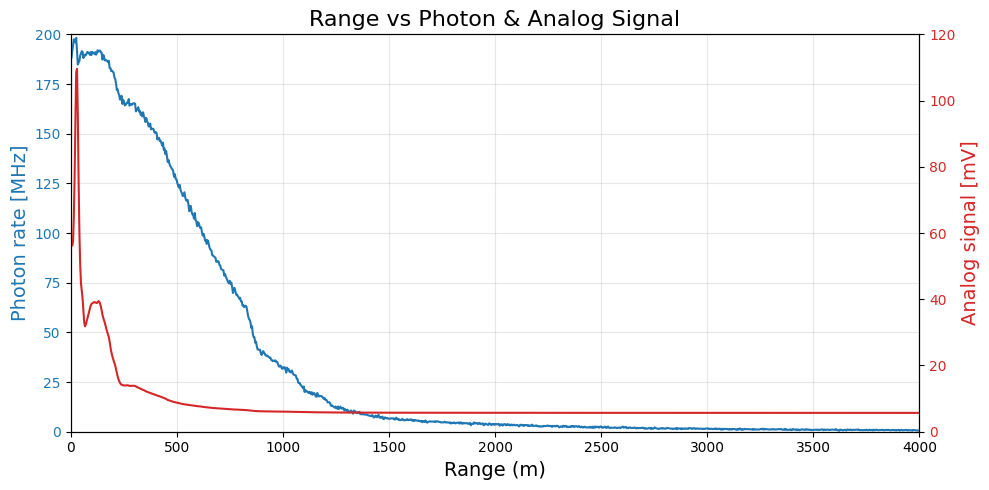

In [15]:
fig, ax1 = plt.subplots(figsize=(10,5))

# Left y-axis (Photon)
ax1.plot(df_Sig["range_m"], df_Sig["photon_counting"], color="tab:blue", label="Photon rate")
ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Photon rate [MHz]", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_ylim(0, 200)
ax1.set_xlim(0, 4000)
ax1.grid(True, alpha=0.3)

# Right y-axis (Analog)
ax2 = ax1.twinx()
ax2.plot(df_Sig["range_m"], df_Sig["analog"], color="tab:red", label="Analog signal")
ax2.set_ylabel("Analog signal [mV]", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.set_xlim(0, 4000)
ax2.set_ylim(0, 120)
plt.title("Range vs Photon & Analog Signal", fontsize=16)
plt.tight_layout()
plt.savefig("SPC/PCvsAC_15000_plot.png", dpi=1000)
plt.show()


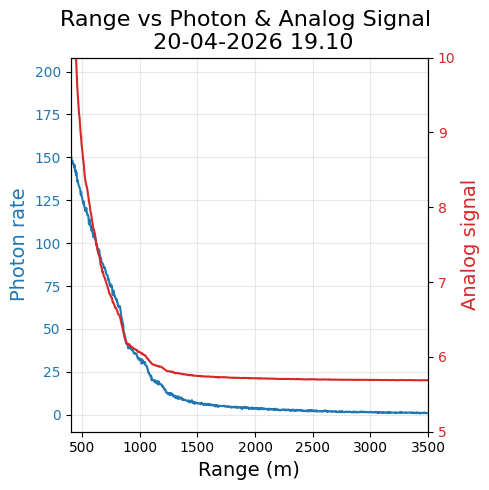

In [39]:
fig, ax1 = plt.subplots(figsize=(5,5))

# Left y-axis (Photon)
ax1.plot(df_Sig["range_m"], df_Sig["photon_counting"], color="tab:blue", label="Photon rate")
ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Photon rate", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Right y-axis (Analog)
ax2 = ax1.twinx()
ax2.plot(df_Sig["range_m"], df_Sig["analog"], color="tab:red", label="Analog signal")
ax2.set_ylabel("Analog signal", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")
ax1.set_xlim(400, 3500)
ax2.set_ylim(5, 10)
plt.title("Range vs Photon & Analog Signal \n 20-04-2026 19.10", fontsize=16)
plt.tight_layout()
plt.show()


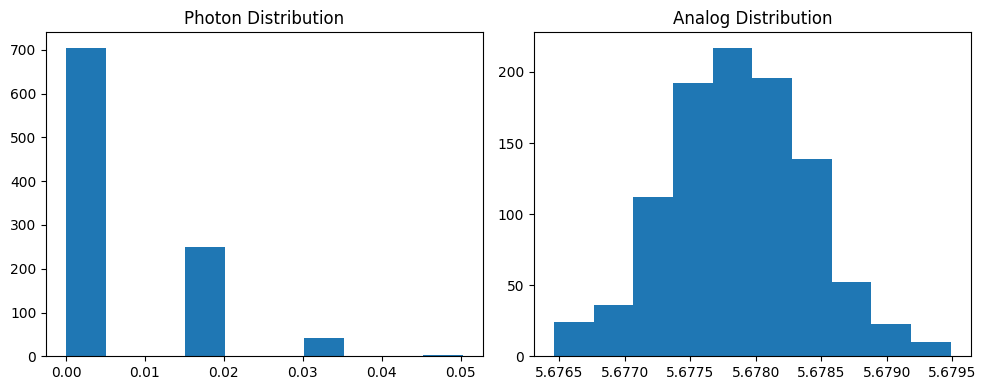

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

ax1.hist(df_Pre["photon_counting"], bins=10)
ax1.set_title("Photon Distribution")

ax2.hist(df_Pre["analog"], bins=10)
ax2.set_title("Analog Distribution")

plt.tight_layout()
plt.show()

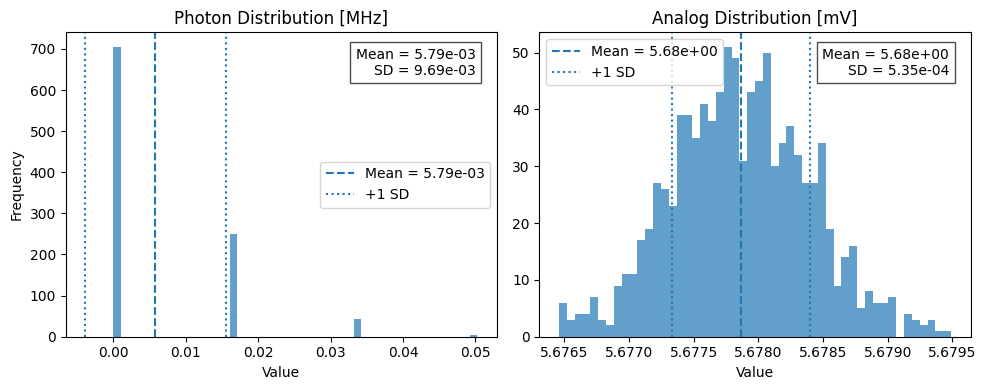

In [43]:
import numpy as np
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

# -------------------------
# Photon
# -------------------------
photon = df_Pre["photon_counting"].dropna()

mu_p = photon.mean()
std_p = photon.std()

ax1.hist(photon, bins=50, alpha=0.7)
ax1.axvline(mu_p, linestyle="--", label=f"Mean = {mu_p:.2e}")
ax1.axvline(mu_p + std_p, linestyle=":", label=f"+1 SD")
ax1.axvline(mu_p - std_p, linestyle=":")

ax1.set_title("Photon Distribution [MHz]")
ax1.set_xlabel("Value")
ax1.set_ylabel("Frequency")

# text box
ax1.text(
    0.95, 0.95,
    f"Mean = {mu_p:.2e}\nSD = {std_p:.2e}",
    transform=ax1.transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.7)
)

ax1.legend()

# -------------------------
# Analog
# -------------------------
analog = df_Pre["analog"].dropna()

mu_a = analog.mean()
std_a = analog.std()

ax2.hist(analog, bins=50, alpha=0.7)
ax2.axvline(mu_a, linestyle="--", label=f"Mean = {mu_a:.2e}")
ax2.axvline(mu_a + std_a, linestyle=":", label="+1 SD")
ax2.axvline(mu_a - std_a, linestyle=":")

ax2.set_title("Analog Distribution [mV]")
ax2.set_xlabel("Value")

# text box
ax2.text(
    0.95, 0.95,
    f"Mean = {mu_a:.2e}\nSD = {std_a:.2e}",
    transform=ax2.transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.7)
)

ax2.legend()

plt.tight_layout()
plt.show()

In [75]:
#Find Background for Photon per Bin Rate and Analog Signal
# df_Pre = df[(df["range_m"] >= 0) & (df["range_m"] <= 3750)]
bg_row = df[(df["range_m"] >= config["bg_start_m"]) & (df["range_m"] <= config["bg_end_m"])]

Analog_bg_mean = bg_row["analog"].mean()
Photon_bg_mean = bg_row["photon_per_bin"].mean()

#Show Background value
print("Analog background (mean):", Analog_bg_mean)
print("Photon Per Bin background (mean):", Photon_bg_mean)

Analog background (mean): 5.677865934065934
Photon Per Bin background (mean): 0.00014480681818181815


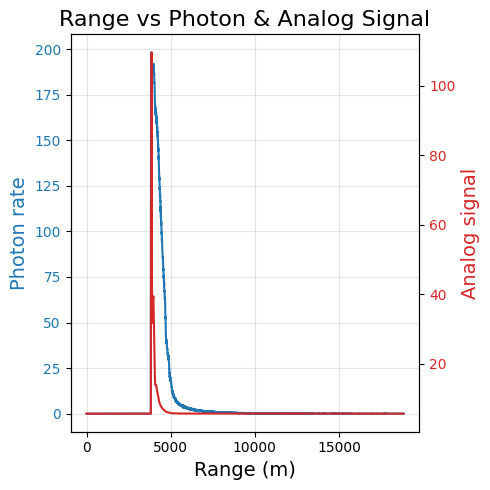

In [77]:
fig, ax1 = plt.subplots(figsize=(5,5))

# Left y-axis (Photon)
ax1.plot(df["range_m"], df["photon_counting"], color="tab:blue", label="Photon rate")
ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Photon rate", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Right y-axis (Analog)
ax2 = ax1.twinx()
ax2.plot(df["range_m"], df["analog"], color="tab:red", label="Analog signal")
ax2.set_ylabel("Analog signal", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Range vs Photon & Analog Signal", fontsize=16)
plt.tight_layout()
plt.show()

In [79]:
df_Sig

,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,SNR_analog,SNR_Photon,photon_per_bin
1024,0,0.00,56.95660,0.104699,188.320000,0.872749,0.0,544.003286,215.777961,4.708000
1025,1,3.75,57.39910,0.104002,188.085000,0.883384,0.0,551.903810,212.914203,4.702125
1026,2,7.50,56.19100,0.119323,191.638000,0.868976,0.0,470.915079,220.533133,4.790950
1027,3,11.25,57.43770,0.143680,194.319000,0.868632,0.0,399.761275,223.706932,4.857975
1028,4,15.00,64.99370,0.185809,197.486000,0.866574,0.0,349.787685,227.892829,4.937150
...,...,...,...,...,...,...,...,...,...,...
5019,3995,14981.25,5.67858,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000
5020,3996,14985.00,5.67835,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000
5021,3997,14988.75,5.67865,0.000000,0.016757,0.000000,0.0,inf,inf,0.000419
5022,3998,14992.50,5.67810,0.000000,0.033515,0.000000,0.0,inf,inf,0.000838


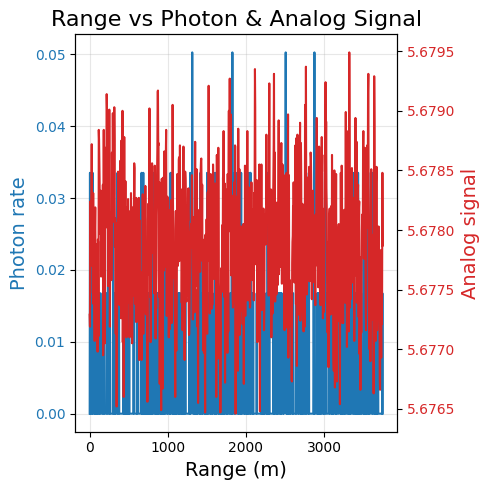

In [81]:
fig, ax1 = plt.subplots(figsize=(5,5))

# Left y-axis (Photon)
ax1.plot(bg_row["range_m"], bg_row["photon_counting"], color="tab:blue", label="Photon rate")
ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Photon rate", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Right y-axis (Analog)
ax2 = ax1.twinx()
ax2.plot(bg_row["range_m"], bg_row["analog"], color="tab:red", label="Analog signal")
ax2.set_ylabel("Analog signal", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Range vs Photon & Analog Signal", fontsize=16)
plt.tight_layout()
plt.show()

In [83]:
df_Sig = df_Sig.copy()
df_Sig["analog_bg_corr"] = df_Sig["analog"] - Analog_bg_mean
df_Sig["Photon_per_bin_bg_corr"] = df_Sig["photon_per_bin"] - Photon_bg_mean

df_Sig["afterpulse_raw"] = AfterPulse["afterpulse_raw"]
df_Sig["afterpulse_counts_per_bin"] = (
    df_Sig["afterpulse_raw"] * config["bin_width_ns"] * 1e-3
)

df_Sig["photon_APcorr_counts"] = (
    df_Sig["Photon_per_bin_bg_corr"] - df_Sig["afterpulse_counts_per_bin"]
)

bin_width_s = config["bin_width_ns"] * 1e-9
dead_time_s = config["dead_time_ns"] * 1e-9

df_Sig["photon_deadtime_counts"] = (
    df_Sig["photon_APcorr_counts"]
    / (1 - df_Sig["photon_APcorr_counts"] * dead_time_s / bin_width_s)
)

# It will be invalid in this case
ratio = df_Sig["photon_deadtime_counts"] * dead_time_s / bin_width_s

df_Sig["photon_deadtime_corr"] = np.where(
    ratio < 1,
    df_Sig["photon_deadtime_counts"] / (1 - ratio),
    np.nan  # invalid / saturated
)

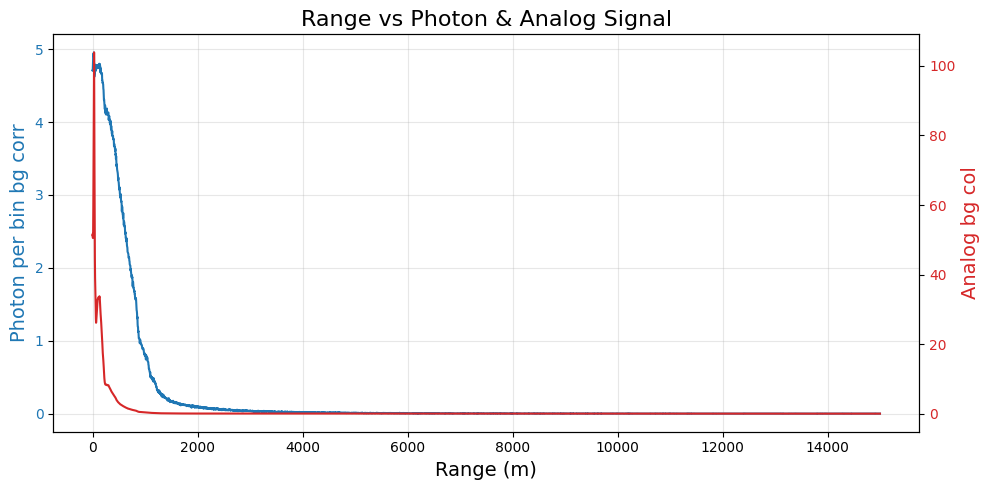

In [85]:
fig, ax1 = plt.subplots(figsize=(10,5))

# Left y-axis (Photon)
ax1.plot(df_Sig["range_m"], df_Sig["Photon_per_bin_bg_corr"], color="tab:blue", label="Photon rate")
ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Photon per bin bg corr", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Right y-axis (Analog)
ax2 = ax1.twinx()
ax2.plot(df_Sig["range_m"], df_Sig["analog_bg_corr"], color="tab:red", label="Analog signal")
ax2.set_ylabel("Analog bg col", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")


plt.title("Range vs Photon & Analog Signal", fontsize=16)
plt.tight_layout()
plt.show()


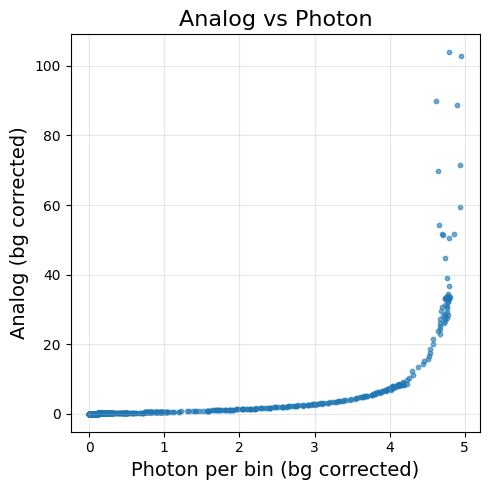

In [87]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5,5))

ax.scatter(
    df_Sig["Photon_per_bin_bg_corr"],
    df_Sig["analog_bg_corr"],
    s=10,
    alpha=0.6
)

ax.set_xlabel("Photon per bin (bg corrected)", fontsize=14)
ax.set_ylabel("Analog (bg corrected)", fontsize=14)
ax.set_title("Analog vs Photon", fontsize=16)

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

k_scale = 2.7033455027331192 b_offset = -0.0025774472416640534 R^2 = 0.5092045422784954


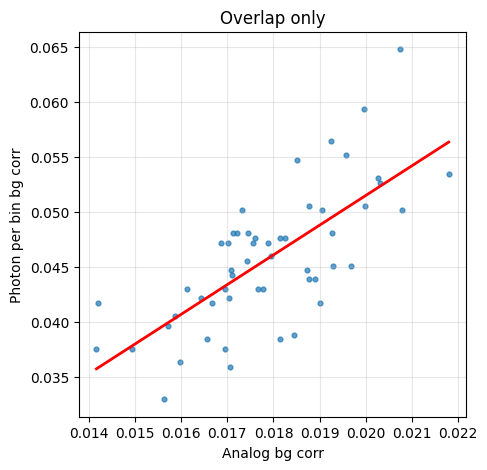

In [89]:
# --- overlap region from df_Sig ---
m_overlap = df_Sig[
    (df_Sig["range_m"] >= config["overlap_r1_m"]) &
    (df_Sig["range_m"] <= config["overlap_r2_m"])
]

x = m_overlap["analog_bg_corr"].to_numpy()
y = m_overlap["Photon_per_bin_bg_corr"].to_numpy()

k_scale, b_offset, r, *_ = linregress(x, y)

print("k_scale =", k_scale,
      "b_offset =", b_offset,
      "R^2 =", r**2)

#visualized
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(m_overlap["analog_bg_corr"], m_overlap["Photon_per_bin_bg_corr"], s=12, alpha=0.7)

xfit = np.linspace(m_overlap["analog_bg_corr"].min(), m_overlap["analog_bg_corr"].max(), 100)
yfit = k_scale * xfit + b_offset
ax.plot(xfit, yfit, color="red", lw=2)

ax.set_xlabel("Analog bg corr")
ax.set_ylabel("Photon per bin bg corr")
ax.set_title("Overlap only")
ax.grid(True, alpha=0.3)
plt.show()

# --- scale analog ---
df_Sig["analog_scaled_for_glue"] = (
    k_scale * df_Sig["analog_bg_corr"] + b_offset
)

# --- blend region ---
blend_r1_m = config["overlap_r1_m"] - 100
blend_r2_m = config["overlap_r2_m"] + 100

r = df_Sig["range_m"].to_numpy()

w = np.zeros_like(r, dtype=float)

# r > r2 → photon dominates
w[r > blend_r2_m] = 1.0

# cosine blend
m = (r >= blend_r1_m) & (r <= blend_r2_m)
w[m] = 0.5 * (
    1.0 - np.cos(np.pi * (r[m] - blend_r1_m) / (blend_r2_m - blend_r1_m))
)

df_Sig["weight_w"] = w

# --- merge ---
df_Sig["merged_counts_per_bin"] = (
    (1.0 - df_Sig["weight_w"]) * df_Sig["analog_scaled_for_glue"]
    + df_Sig["weight_w"] * df_Sig["Photon_per_bin_bg_corr"]
)

# --- range² correction ---
df_Sig["range2_corrected_counts"] = (
    df_Sig["merged_counts_per_bin"] * df_Sig["range_m"]**2
)

# --- normalization ---
df_Sig["range2_norm"] = (
    df_Sig["range2_corrected_counts"] /
    df_Sig["range2_corrected_counts"].max()
)

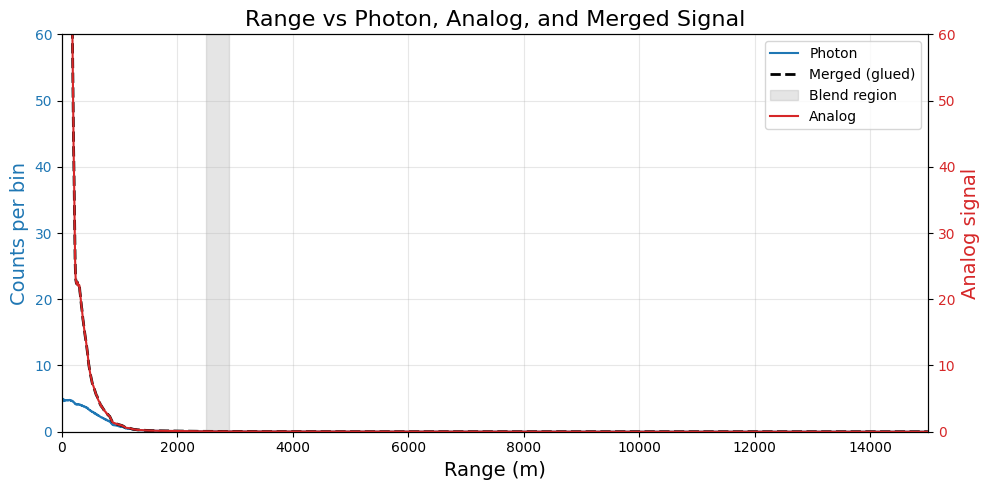

In [91]:
fig, ax1 = plt.subplots(figsize=(10,5))

# --- Left y-axis: Photon + Merged ---
ax1.plot(
    df_Sig["range_m"],
    df_Sig["Photon_per_bin_bg_corr"],
    color="tab:blue",
    label="Photon"
)

ax1.plot(
    df_Sig["range_m"],
    df_Sig["merged_counts_per_bin"],
    color="black",
    linestyle="--",
    linewidth=2,
    label="Merged (glued)"
)

ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Counts per bin", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# --- Blend region ---
ax1.axvspan(
    blend_r1_m,
    blend_r2_m,
    color="gray",
    alpha=0.2,
    label="Blend region"
)

ax1.set_xlim(0, 15000)
ax1.set_ylim(0, 60)
# --- Right y-axis: Analog ---
ax2 = ax1.twinx()
ax2.plot(
    df_Sig["range_m"],
    df_Sig["analog_scaled_for_glue"],
    color="tab:red",
    label="Analog"
)

ax2.set_ylabel("Analog signal", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.set_ylim(0, 60)

# --- Legend (combine both axes) ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.title("Range vs Photon, Analog, and Merged Signal", fontsize=16)
plt.tight_layout()
plt.show()

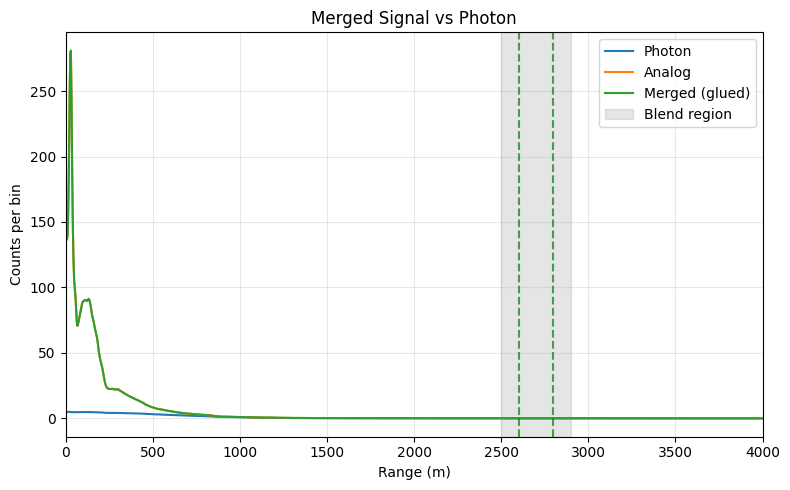

In [93]:
def plot_vs_range(
    df,
    ycols,
    *,
    xcol="range_m",
    labels=None,
    title=None,
    xlabel="Range (m)",
    ylabel=None,
    yscale="linear",
    xlim=None,
    ylim=None,
    figsize=(8,5),
    blend_region=None,      # (r1, r2)
    overlap_region=None,    # (r1, r2)
):
    plt.figure(figsize=figsize)

    if labels is None:
        labels = ycols

    for y, lab in zip(ycols, labels):
        plt.plot(df[xcol], df[y], label=lab)

    # --- Blend region ---
    if blend_region:
        plt.axvspan(
            blend_region[0],
            blend_region[1],
            color="gray",
            alpha=0.2,
            label="Blend region"
        )

    # --- Overlap region ---
    if overlap_region:
        plt.axvline(overlap_region[0], color="green", linestyle="--", alpha=0.7)
        plt.axvline(overlap_region[1], color="green", linestyle="--", alpha=0.7)

    plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    if title:
        plt.title(title)

    plt.yscale(yscale)

    if xlim:
        plt.xlim(*xlim)
    if ylim:
        plt.ylim(*ylim)

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_vs_range(
    df_Sig,
    ycols=[
        "Photon_per_bin_bg_corr",
        "analog_scaled_for_glue",
        "merged_counts_per_bin",
    ],
    labels=[
        "Photon",
        "Analog",
        "Merged (glued)",
    ],
    ylabel="Counts per bin",
    yscale="linear",
    xlim=(0, 4000),
    title="Merged Signal vs Photon",
    blend_region=(blend_r1_m, blend_r2_m),
    overlap_region=(config["overlap_r1_m"], config["overlap_r2_m"]),
)

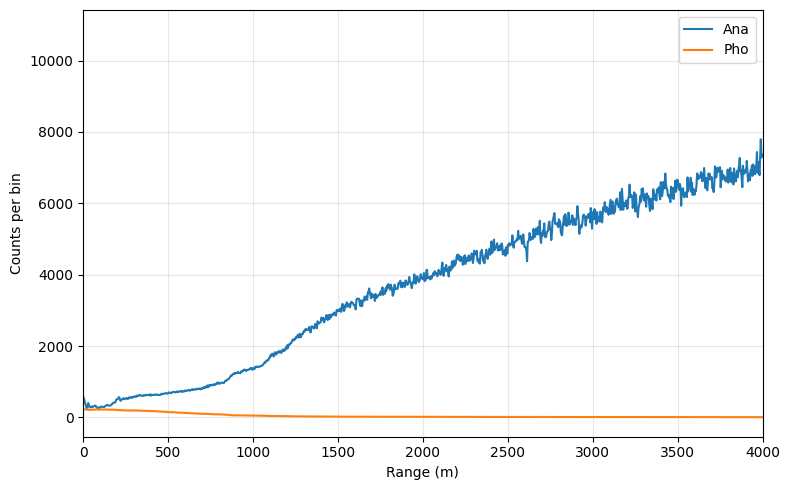

In [95]:
plot_vs_range(
    df_Sig,
    ycols=[
        "SNR_analog",
        "SNR_Photon",
    ],
    labels=[
        "Ana",
        "Pho",
    ],
    ylabel="Counts per bin",
    yscale="linear",
    xlim=(0, 4000),
    # title="Merged Signal vs Photon",
    # blend_region=(blend_r1_m, blend_r2_m),
    # overlap_region=(config["overlap_r1_m"], config["overlap_r2_m"]),
)

In [97]:
df_Sig

,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,SNR_analog,SNR_Photon,photon_per_bin,...,afterpulse_raw,afterpulse_counts_per_bin,photon_APcorr_counts,photon_deadtime_counts,photon_deadtime_corr,analog_scaled_for_glue,weight_w,merged_counts_per_bin,range2_corrected_counts,range2_norm
1024,0,0.00,56.95660,0.104699,188.320000,0.872749,0.0,544.003286,215.777961,4.708000,...,0.0,0.0,4.707855,11.109759,NaN,138.621558,0.0,138.621558,0.000000,0.000000
1025,1,3.75,57.39910,0.104002,188.085000,0.883384,0.0,551.903810,212.914203,4.702125,...,0.0,0.0,4.701980,11.077098,NaN,139.817788,0.0,139.817788,1966.187645,0.000824
1026,2,7.50,56.19100,0.119323,191.638000,0.868976,0.0,470.915079,220.533133,4.790950,...,0.0,0.0,4.790805,11.583032,NaN,136.551876,0.0,136.551876,7681.043045,0.003219
1027,3,11.25,57.43770,0.143680,194.319000,0.868632,0.0,399.761275,223.706932,4.857975,...,0.0,0.0,4.857830,11.982761,NaN,139.922137,0.0,139.922137,17708.895489,0.007422
1028,4,15.00,64.99370,0.185809,197.486000,0.866574,0.0,349.787685,227.892829,4.937150,...,0.0,0.0,4.937005,12.476304,NaN,160.348616,0.0,160.348616,36078.438559,0.015121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5019,3995,14981.25,5.67858,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,-0.000647,1.0,-0.000145,-32500.131164,-0.013621
5020,3996,14985.00,5.67835,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,-0.001269,1.0,-0.000145,-32516.403604,-0.013628
5021,3997,14988.75,5.67865,0.000000,0.016757,0.000000,0.0,inf,inf,0.000419,...,NaN,NaN,NaN,NaN,NaN,-0.000458,1.0,0.000274,61586.357342,0.025811
5022,3998,14992.50,5.67810,0.000000,0.033515,0.000000,0.0,inf,inf,0.000838,...,NaN,NaN,NaN,NaN,NaN,-0.001945,1.0,0.000693,155783.877616,0.065290


In [99]:
m_overlap = (
    (df_Sig["range_m"] >= config["overlap_r1_m"]) &
    (df_Sig["range_m"] <= config["overlap_r2_m"])
)

ratio = (
    df_Sig.loc[m_overlap, "analog_scaled_for_glue"] /
    df_Sig.loc[m_overlap, "photon_APcorr_counts"]
)

#On average, the scaled analog signal is (ratio mean - 1) * 100 % higher than the photon signal in the overlap region.
print("ratio mean:", ratio.mean())
#How much the ratio fluctuates from bin to bin around the mean.
print("ratio std :", ratio.std())

ratio mean: nan
ratio std : nan


In [101]:
df

,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,SNR_analog,SNR_Photon,photon_per_bin
0,0,0.00,5.67729,0.000537,0.000000,0.000000,0.0,1.057838e+04,NaN,0.000000
1,1,3.75,5.67719,0.000549,0.033515,0.023671,0.0,1.034732e+04,1.415845,0.000838
2,2,7.50,5.67824,0.000538,0.000000,0.000000,0.0,1.055184e+04,NaN,0.000000
3,3,11.25,5.67797,0.000541,0.016757,0.016810,0.0,1.049899e+04,0.996871,0.000419
4,4,15.00,5.67770,0.000542,0.000000,0.000000,0.0,1.048455e+04,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...
5019,5019,18821.25,5.67858,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000
5020,5020,18825.00,5.67835,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000
5021,5021,18828.75,5.67865,0.000000,0.016757,0.000000,0.0,inf,inf,0.000419
5022,5022,18832.50,5.67810,0.000000,0.033515,0.000000,0.0,inf,inf,0.000838


In [104]:
#MiniMPL
MiniMPL = pd.read_csv("/Users/thunthita/LidarNRBPipeline/LIDar/RawFile/25-03-2026-DATfile/MPL_5038_202603250505.csv")
MiniMPL["range_raw"]

0       0.029979
1       0.059958
2       0.089938
3       0.119917
4       0.149896
         ...    
995    29.859330
996    29.889309
997    29.919287
998    29.949266
999    29.979246
Name: range_raw, Length: 1000, dtype: float64

In [106]:
# Select + rename columns
MiniMPL_for_process = pd.DataFrame({
    "range_raw": MiniMPL["range_raw"],
    "range (m) for NRB": MiniMPL["range_raw"]*1000,
    "range (m)": MiniMPL["range_nrb"]*1000,
    "copol_raw": MiniMPL["copol_raw"],
    "copol_snr": MiniMPL["copol_snr"],
    "copol_nrb": MiniMPL["copol_nrb"],
    "pbls": MiniMPL["pbls"],
    "Normalize_copol_nrb": MiniMPL["copol_nrb"]/MiniMPL["copol_nrb"].max(),
})

# Save to CSV
MiniMPL_for_process.to_csv("MiniMPL_for_process_202603250505.csv", index=False)

In [108]:
MiniMPL_for_process = pd.read_csv("MiniMPL_for_process_202603250505.csv")
MiniMPL_for_process

,range_raw,range (m) for NRB,range (m),copol_raw,copol_snr,copol_nrb,pbls,Normalize_copol_nrb
0,0.029979,29.979246,119.91698,25.023903,82353.590000,0.372730,0.899377,0.754327
1,0.059958,59.958490,149.89623,18.891552,62081.992000,0.457651,NaN,0.926187
2,0.089938,89.937740,179.87548,12.776767,42041.830000,0.494123,NaN,1.000000
3,0.119917,119.916980,209.85472,13.388546,43984.110000,0.470819,NaN,0.952839
4,0.149896,149.896230,239.83397,15.770059,51881.344000,0.378892,NaN,0.766796
...,...,...,...,...,...,...,...,...
995,29.859330,29859.330000,NaN,0.000922,0.500619,NaN,NaN,NaN
996,29.889309,29889.309000,NaN,0.000625,-0.400829,NaN,NaN,NaN
997,29.919287,29919.287000,NaN,0.000729,-0.082529,NaN,NaN,NaN
998,29.949266,29949.266000,NaN,0.000625,-0.491179,NaN,NaN,NaN


In [110]:
# plot_xy(
#     MiniMPL_for_process,
#     xcol="range_raw",
#     ycol="copol_raw",
#     yscale="linear",
#     title="Range Raw vs Copol Raw (MiniMPL)",
#     xlabel="Range Raw (m)",
#     ylabel="Copol Raw",
#     outfile="RawFilePicforExample/MiniMPL/Range_Raw_vs_Copol_Raw(MiniMPL).png",
# )

In [112]:
# plot_xy(
#     MiniMPL_for_process,
#     xcol="range_raw",
#     ycol="copol_snr",
#     yscale="linear",
#     title="Range Raw vs Copol SNR (MiniMPL)",
#     xlabel="Range Raw (m)",
#     ylabel="Copol SNR",
#     outfile="RawFilePicforExample/MiniMPL/Range_Raw_vs_Copol_SNR(MiniMPL).png",
# )

In [114]:
# plot_xy(
#     MiniMPL_for_process,
#     xcol="range_raw",
#     ycol="copol_nrb",
#     yscale="linear",
#     title="Range Raw vs Copol NRB (MiniMPL)",
#     xlabel="Range Raw (m)",
#     ylabel="Copol NRB",
#     outfile="RawFilePicforExample/MiniMPL/Range_Raw_vs_Copol_NRB(MiniMPL).png",
# )

In [116]:
# plot_xy(
#     MiniMPL_for_process,
#     xcol="range_raw",
#     ycol="Normalize copol nrb",
#     yscale="linear",
#     title="Range Raw vs Normalize Copol NRB (MiniMPL)",
#     xlabel="Range Raw (m)",
#     ylabel="Normalize Copol NRB",
#     outfile="RawFilePicforExample/MiniMPL/Range_Raw_vs_Normalize_copol_nrb(MiniMPL).png",
# )

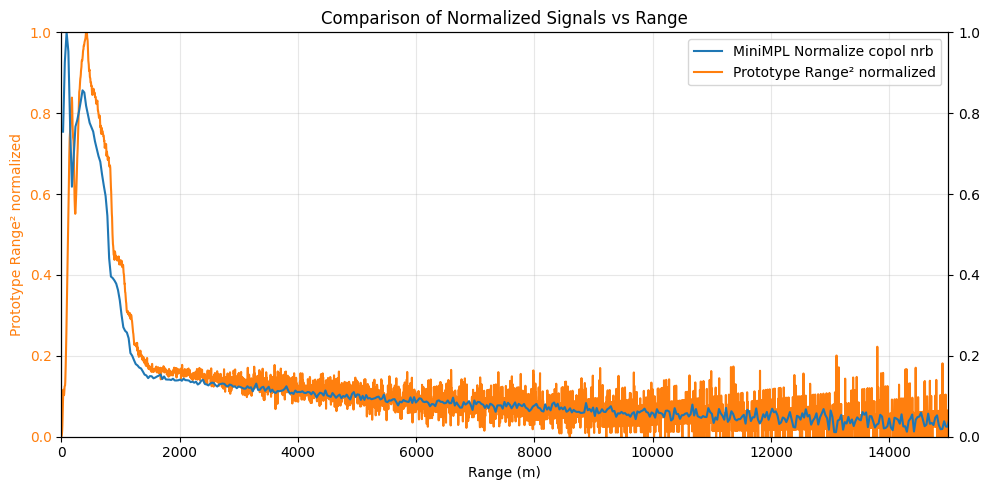

In [118]:
fig, ax1 = plt.subplots(figsize=(10,5))

# ---- Left axis (Prototype) ----
color1 = "tab:orange"

ax1.plot(
    df_Sig["range_m"],
    df_Sig["range2_norm"],
    label="Prototype Range² normalized",
    color=color1,
)

ax1.set_xlabel("Range (m)")
ax1.set_ylabel("Prototype Range² normalized", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.set_xlim(0,15000)
ax1.set_ylim(0,1)

# ---- Right axis (MiniMPL) ----
ax2 = ax1.twinx()

color2 = "tab:blue"

ax2.plot(
    MiniMPL_for_process["range (m) for NRB"],
    MiniMPL_for_process["Normalize_copol_nrb"],
    label="MiniMPL Normalize copol nrb",
    color=color2,
)

# ax2.set_ylabel("MiniMPL Normalized NRB", color=color2)
# ax2.tick_params(axis="y", labelcolor=color2)
ax2.set_ylim(0,1)
# ---- Title / grid ----
ax1.set_title("Comparison of Normalized Signals vs Range")
ax1.grid(True, alpha=0.3)

# ---- Combined legend (MiniMPL first) ----
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines2 + lines1, labels2 + labels1)

plt.tight_layout()
plt.show()

In [119]:
import numpy as np
import pandas as pd
from scipy.stats import linregress

def auto_detect_overlap_region(
    df,
    analog_col="analog",
    photon_col="photon_counting",
    range_col="range_m",
    r_min=100,
    r_max=3000,
    window_m=150,
    step_m=25,
    min_points=20,
    r2_min=0.95,
):
    results = []

    for start in np.arange(r_min, r_max - window_m + step_m, step_m):
        end = start + window_m

        d = df[
            (df[range_col] >= start) &
            (df[range_col] <= end)
        ][[range_col, analog_col, photon_col]].copy()

        # clean
        d = d.replace([np.inf, -np.inf], np.nan).dropna()
        d = d[(d[analog_col] > 0) & (d[photon_col] > 0)]

        if len(d) < min_points:
            continue

        x = d[analog_col].to_numpy()
        y = d[photon_col].to_numpy()

        slope, intercept, r, p, stderr = linregress(x, y)
        r2 = r**2

        # optional extra metric: relative residual
        y_fit = slope * x + intercept
        rmse = np.sqrt(np.mean((y - y_fit)**2))
        rel_rmse = rmse / np.mean(y)

        results.append({
            "start_m": start,
            "end_m": end,
            "n_points": len(d),
            "slope": slope,
            "intercept": intercept,
            "r2": r2,
            "rel_rmse": rel_rmse,
        })

    results_df = pd.DataFrame(results)

    if results_df.empty:
        return None, None

    # keep only physically reasonable windows
    candidates = results_df[
        (results_df["slope"] > 0) &
        (results_df["r2"] >= r2_min)
    ].copy()

    if candidates.empty:
        # fallback: choose highest R²
        best = results_df.sort_values(
            by=["r2", "rel_rmse"],
            ascending=[False, True]
        ).iloc[0]
    else:
        # choose best by high R² + low residual
        best = candidates.sort_values(
            by=["r2", "rel_rmse"],
            ascending=[False, True]
        ).iloc[0]

    return best, results_df


best, scan_table = auto_detect_overlap_region(
    df_Sig,
    r_min=100,
    r_max=5000,
    window_m=300,
    step_m=25,
    min_points=20,
    r2_min=0.95,
)

print(best)

start_m       900.000000
end_m        1200.000000
n_points       81.000000
slope          75.632129
intercept    -425.924824
r2              0.995338
rel_rmse        0.018774
Name: 32, dtype: float64


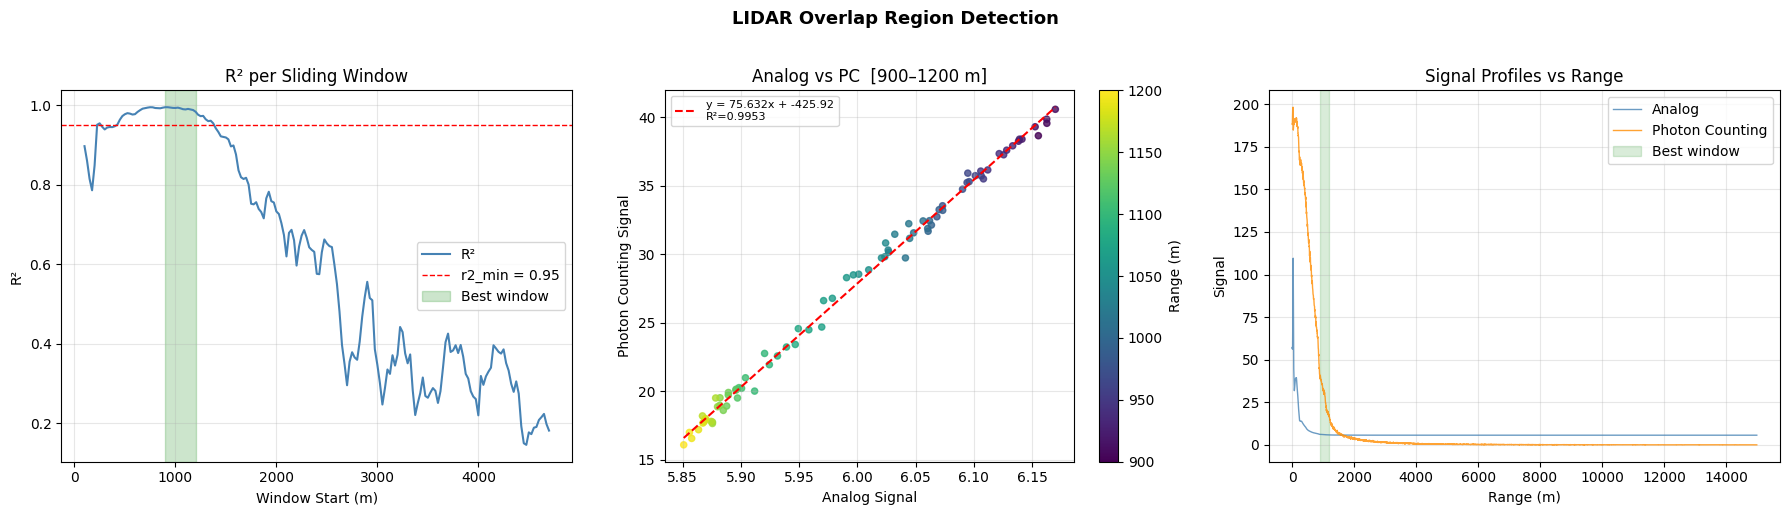

In [121]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1. R² across all scanned windows ──────────────────────────────────────
ax1 = axes[0]
ax1.plot(scan_table["start_m"], scan_table["r2"], color="steelblue", lw=1.5, label="R²")
ax1.axhline(0.95, color="red", ls="--", lw=1, label="r2_min = 0.95")
if best is not None:
    ax1.axvspan(best["start_m"], best["end_m"], alpha=0.2, color="green", label="Best window")
ax1.set_xlabel("Window Start (m)")
ax1.set_ylabel("R²")
ax1.set_title("R² per Sliding Window")
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── 2. Analog vs Photon Counting — best window only ───────────────────────
ax2 = axes[1]
if best is not None:
    d_best = df_Sig[
        (df_Sig["range_m"] >= best["start_m"]) &
        (df_Sig["range_m"] <= best["end_m"])
    ].replace([np.inf, -np.inf], np.nan).dropna(subset=["analog", "photon_counting"])
    d_best = d_best[(d_best["analog"] > 0) & (d_best["photon_counting"] > 0)]

    ax2.scatter(d_best["analog"], d_best["photon_counting"],
                c=d_best["range_m"], cmap="viridis", s=20, alpha=0.8)

    # fitted line
    x_line = np.linspace(d_best["analog"].min(), d_best["analog"].max(), 200)
    y_line = best["slope"] * x_line + best["intercept"]
    ax2.plot(x_line, y_line, "r--", lw=1.5,
             label=f"y = {best['slope']:.3f}x + {best['intercept']:.2f}\nR²={best['r2']:.4f}")

    sm = cm.ScalarMappable(cmap="viridis",
                           norm=plt.Normalize(d_best["range_m"].min(), d_best["range_m"].max()))
    plt.colorbar(sm, ax=ax2, label="Range (m)")
    ax2.set_xlabel("Analog Signal")
    ax2.set_ylabel("Photon Counting Signal")
    ax2.set_title(f"Analog vs PC  [{best['start_m']:.0f}–{best['end_m']:.0f} m]")
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

# ── 3. Both signals vs Range — full profile ───────────────────────────────
ax3 = axes[2]
df_clean = df_Sig.replace([np.inf, -np.inf], np.nan).dropna(subset=["analog", "photon_counting"])
df_clean = df_clean[(df_clean["analog"] > 0) & (df_clean["photon_counting"] > 0)]

ax3.plot(df_clean["range_m"], df_clean["analog"],
         color="steelblue", lw=1, alpha=0.8, label="Analog")
ax3.plot(df_clean["range_m"], df_clean["photon_counting"],
         color="darkorange", lw=1, alpha=0.8, label="Photon Counting")

if best is not None:
    ax3.axvspan(best["start_m"], best["end_m"], alpha=0.15, color="green", label="Best window")

ax3.set_xlabel("Range (m)")
ax3.set_ylabel("Signal")
ax3.set_title("Signal Profiles vs Range")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.suptitle("LIDAR Overlap Region Detection", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [122]:
#MiniMPL
NRB_processed = pd.read_csv("/Users/thunthita/LidarNRBPipeline/LIDar/ExampleCode/Pipeline_Test/lidar_output.csv")
NRB_processed

,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,photon_counting_shifted,photon_deadtime_corr,analog_scaled_for_glue,weight_w,merged_sig,merged_sig_bg_corr,range2_corrected_counts,nrb,range2_norm
0,0,0.00,131.00800,0.183648,192.344000,0.870157,0.0,192.344000,467.504154,13445.719455,0.0,13445.719455,13445.705639,0.000000e+00,0.000000e+00,0.000000
1,1,3.75,135.27300,0.202470,193.611000,0.895029,1.0,193.611000,475.060332,13904.021989,0.0,13904.021989,13904.008174,1.955251e+05,7.821005e+06,0.000050
2,2,7.50,129.84500,0.168341,197.281000,0.878675,0.0,197.281000,497.781919,13320.747392,0.0,13320.747392,13320.733576,7.492913e+05,2.997165e+07,0.000191
3,3,11.25,129.66400,0.151196,199.416000,0.886170,1.0,199.416000,511.602438,13301.297742,0.0,13301.297742,13301.283926,1.683444e+06,6.733775e+07,0.000429
4,4,15.00,144.84000,0.239346,202.952000,0.890940,0.0,202.952000,535.540203,14932.059586,0.0,14932.059586,14932.045770,3.359710e+06,1.343884e+08,0.000856
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3995,14981.25,5.88172,0.000000,0.133445,0.000000,0.0,0.133445,0.133500,0.070855,1.0,0.133500,0.119684,2.686159e+07,1.074464e+09,0.006846
3996,3996,14985.00,5.88245,0.000000,0.216847,0.000000,0.0,0.216847,0.216991,0.149298,1.0,0.216991,0.203175,4.562307e+07,1.824923e+09,0.011628
3997,3997,14988.75,5.88213,0.000000,0.216847,0.000000,0.0,0.216847,0.216991,0.114912,1.0,0.216991,0.203175,4.564590e+07,1.825836e+09,0.011634
3998,3998,14992.50,5.88220,0.000000,0.150125,0.000000,0.0,0.150125,0.150194,0.122434,1.0,0.150194,0.136378,3.065445e+07,1.226178e+09,0.007813


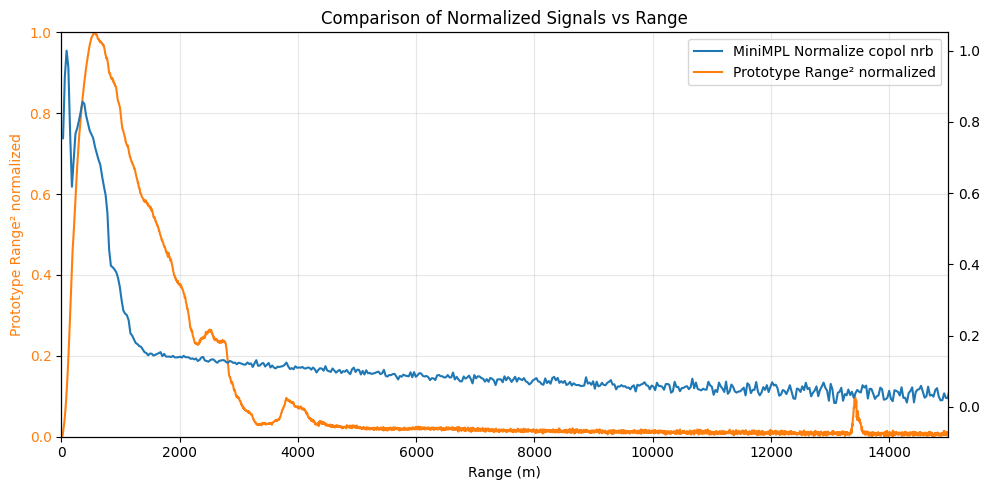

In [124]:
fig, ax1 = plt.subplots(figsize=(10,5))

# ---- Left axis (Prototype) ----
color1 = "tab:orange"

ax1.plot(
    NRB_processed["range_m"],
    NRB_processed["range2_norm"],
    label="Prototype Range² normalized",
    color=color1,
)

ax1.set_xlabel("Range (m)")
ax1.set_ylabel("Prototype Range² normalized", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.set_xlim(0,15000)
ax1.set_ylim(0,1)

# ---- Right axis (MiniMPL) ----
ax2 = ax1.twinx()

color2 = "tab:blue"

ax2.plot(
    MiniMPL_for_process["range (m) for NRB"],
    MiniMPL_for_process["Normalize_copol_nrb"],
    label="MiniMPL Normalize copol nrb",
    color=color2,
)

# ax2.set_ylabel("MiniMPL Normalized NRB", color=color2)
# ax2.tick_params(axis="y", labelcolor=color2)
# ax2.set_ylim(0,1)
# ---- Title / grid ----
ax1.set_title("Comparison of Normalized Signals vs Range")
ax1.grid(True, alpha=0.3)

# ---- Combined legend (MiniMPL first) ----
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines2 + lines1, labels2 + labels1)

plt.tight_layout()
plt.show()